In [1]:
'''
Model of the spread of diseases using discrete time markov chains and graph theory

This code will take in the desired number of time steps (years), the desired number of nodes (people/cities), 
and unique probabilities indicating the probability of getting infected given that you are susceptible (beta),
and the probability of becoming removed once already infected (gamma). 

The built-in information will include the shape and connectivity of the graph, as well as the initial state. The 
initial state includes information about each individiaul node (susceptible, infected, or removed). In this model,
the graph is the complete graph, where each node is connected to every node excluding itself. 

At this stage of development, the initial state will be that 1 node is infected, and the rest are susceptible. 
In future work, we will be given the I.C. from real data.

This model will then output a graph demonstrating the SIR model results of running this simulation 100 times
with the given parameters.

Updates - 3/28/26:
Reducing runtime
'''

'\nModel of the spread of diseases using discrete time markov chains and graph theory\n\nThis code will take in the desired number of time steps (years), the desired number of nodes (people/cities), \nand unique probabilities indicating the probability of getting infected given that you are susceptible (beta),\nand the probability of becoming removed once already infected (gamma). \n\nThe built-in information will include the shape and connectivity of the graph, as well as the initial state. The \ninitial state includes information about each individiaul node (susceptible, infected, or removed). In this model,\nthe graph is the complete graph, where each node is connected to every node excluding itself. \n\nAt this stage of development, the initial state will be that 1 node is infected, and the rest are susceptible. \nIn future work, we will be given the I.C. from real data.\n\nThis model will then output a graph demonstrating the SIR model results of running this simulation 100 times\

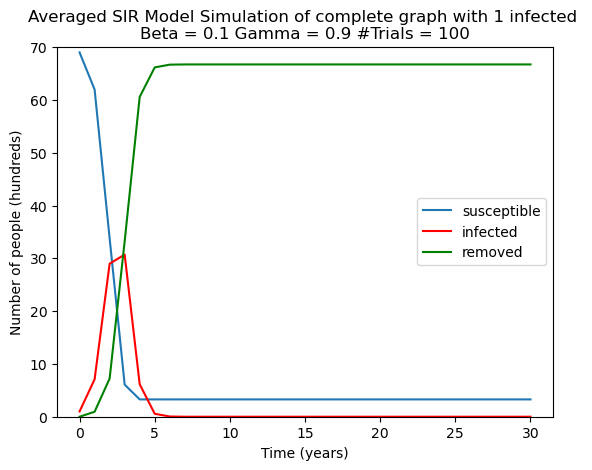

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

'''
Next step: Use real data, creat the two countries example.'
'''

def singlesimulation_SIRModel(nodes, N, beta, gamma):
    I=[1]
    R=[0]
    y=[0]
    num_susceptible = nodes-1    
    S=[num_susceptible,]
    num_infected = I[0]
    num_removed = R[0]
    #Define the adjacency matrix - complete graph
    adj = np.zeros((nodes,nodes))
    adj[0:nodes,0:nodes]=1

    for s in range(nodes):
        adj[s,s] = 0 
    k= len(adj)
    
    #Define inish condish
    init = []
    num=0
    while num < nodes-1:
        init.append(0)
        num+=1
    init.append(1)

    #Define the matrix containing all states/time steps
    X = np.zeros((len(init),N+1))
    i=0
    while i< len(init):
        X[i,0]=init[i]
        i+=1
    
    for t in range(1,N+1): #each time step:
        for j in range(k): #go through each element of the *newest* state, if infected => stays infected
            if X[j, t-1] == -1:
                X[j, t]=-1
            elif X[j, t-1] == 1:
                f = random.random()
                if f<gamma:
                    X[j, t]=-1
                    num_infected-=1
                    num_removed+=1
                else:
                    X[j, t]=1
            elif X[j, t-1]==0:
                n = adj@ X[:, t-1]
                p = 1-((1-beta)**n[j])
                r = random.random()
                if r<p:
                    X[j, t]=1
                    num_infected+=1
                    num_susceptible-=1
                else:
                    X[j, t]=0
            
            
        S.append(num_susceptible)
        I.append(num_infected)
        R.append(num_removed)
        y.append(t)
        
    return S, I, R

def averaged_SIRsim(nodes, beta, gamma, N, runs):    
    sumS = np.zeros((runs, N+1))
    sumI = np.zeros((runs, N+1))
    sumR = np.zeros((runs, N+1))
   
    for i in range(runs):
        S, I, R = singlesimulation_SIRModel(nodes, N, beta, gamma)
        sumS[i,:]=S
        sumI[i,:]=I
        sumR[i,:]=R
    avgS = sumS.mean(axis=0)
    avgI = sumI.mean(axis=0)
    avgR = sumR.mean(axis=0)

    y=np.arange(0,N+1)
    plt.plot(y, avgS, label = "susceptible")
    plt.plot(y, avgI, label = "infected", color = "red")
    plt.plot(y, avgR, label = "removed", color = "green")
    plt.title(f"Averaged SIR Model Simulation of complete graph with 1 infected \nBeta = {beta} Gamma = {gamma} #Trials = {runs}")
    plt.legend()
    plt.xlabel("Time (years)")
    plt.ylabel("Number of people (hundreds)")
    plt.ylim([0,nodes])
    
averaged_SIRsim(70, 0.1, 0.9, 30, 100)

In [4]:
N=5
S = R = I = np.zeros(N)
S[0] = 11
R[0] = 0
I[0] = 1
print(N)
for t in range(1,N):
    S[t]=S[t-1]
    if random.random() < 1:
        S[t]=S[t]-1
print(S)

5
[ 1.  0. -1. -2. -3.]
